<a href="https://colab.research.google.com/github/HugoGarciaArocas1/Research-Innovation-management/blob/main/class_task_Main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q codecarbon datasets pynvml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 402.7/402.7 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 27.0 MB/s eta 0:00:00


# Import CPU

In [ ]:
import os
import time
import threading
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import transforms, models

from datasets import load_dataset, DatasetDict

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from codecarbon import EmissionsTracker

import psutil
import matplotlib.pyplot as plt

# Check Availability of CPU

In [ ]:
device = torch.device("cpu")

print("Device:", device)
print("GPU available:", torch.cuda.is_available())
print("CPU cores:", os.cpu_count())

Device: cpu
GPU available: False
CPU cores: 2


# Load Chest X-ray Dataset

In [ ]:
dataset = load_dataset("hf-vision/chest-xray-pneumonia")

print(dataset)

README.md:   0%|          | 0.00/2.06k [00:00<?, ?B/s]

data/train-00000-of-00007.parquet: reconstructing file:   0%|          |  0.00B /  446MB            

data/train-00000-of-00007.parquet: downloading bytes:           |  0.00B            

data/train-00001-of-00007.parquet: reconstructing file:   0%|          |  0.00B /  385MB            

data/train-00001-of-00007.parquet: downloading bytes:           |  0.00B            

...

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/5216 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/16 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/624 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 5216
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 16
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 624
    })
})


# Creating a Validation set

In [ ]:
split_dataset = dataset["train"].train_test_split(
    test_size=0.15,
    seed=42,
    stratify_by_column="label"
)

dataset = DatasetDict({
    "train": split_dataset["train"],
    "validation": split_dataset["test"],
    "test": dataset["test"]
})

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 4433
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 783
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 624
    })
})


# Checking Class Distribution

In [ ]:
from collections import Counter

train_labels = dataset["train"]["label"]
val_labels = dataset["validation"]["label"]
test_labels = dataset["test"]["label"]

print("Training:", Counter(train_labels))
print("Validation:", Counter(val_labels))
print("Test:", Counter(test_labels))
print("Label names:", dataset["train"].features["label"].names)

Training: Counter({1: 3293, 0: 1140})
Validation: Counter({1: 582, 0: 201})
Test: Counter({1: 390, 0: 234})
Label names: ['NORMAL', 'PNEUMONIA']


# Pre-processing Pipline

In [ ]:
IMAGE_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Image size:", IMAGE_SIZE)
print("Transforms ready.")

Image size: 224
Transforms ready.


# PyTorch Dataset Wrapper
 The Hugging Face dataset contains PIL images. PyTorch needs us to convert each image into a tensor before giving it to the CNN.

In [ ]:
class ChestXRayDataset(torch.utils.data.Dataset):

    def __init__(self, hf_dataset, transform=None):
        self.dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]

        image = item["image"]
        label = item["label"]

        # Convert grayscale X-ray to RGB
        if image.mode != "RGB":
            image = image.convert("RGB")

        # Apply preprocessing
        if self.transform:
            image = self.transform(image)

        return image, label


train_dataset = ChestXRayDataset(
    dataset["train"],
    transform=train_transform
)

val_dataset = ChestXRayDataset(
    dataset["validation"],
    transform=test_transform
)

test_dataset = ChestXRayDataset(
    dataset["test"],
    transform=test_transform
)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

Train dataset: 4433
Validation dataset: 783
Test dataset: 624


# Create Data Loader
Now we tell PyTorch how to feed the images to the models in batches of 32.
Because you only have 2 CPU cores, we'll use num_workers=0.

In [ ]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Batch size:", BATCH_SIZE)
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Batch size: 32
Training batches: 139
Validation batches: 25
Test batches: 20


# Test one Batch

In [ ]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Labels:", labels[:10])
print("Image data type:", images.dtype)

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Labels: tensor([1, 1, 1, 1, 1, 1, 1, 1, 0, 1])
Image data type: torch.float32


# See one X-Ray

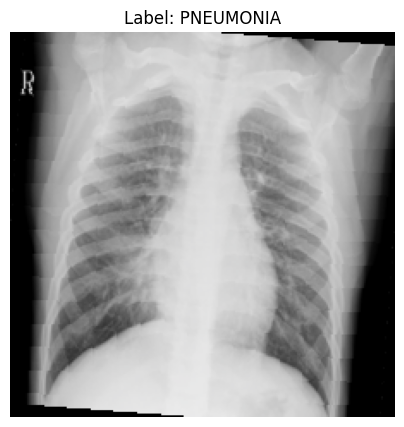

In [ ]:
import matplotlib.pyplot as plt

image, label = train_dataset[0]

# Convert tensor back to displayable image
image_display = image.permute(1, 2, 0).numpy()

# Undo normalization
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

image_display = image_display * std + mean
image_display = np.clip(image_display, 0, 1)

plt.figure(figsize=(5, 5))
plt.imshow(image_display)
plt.title(f"Label: {dataset['train'].features['label'].names[label]}")
plt.axis("off")
plt.show()

# Create the lightweight CNN: MobileNetV3-Small

In [ ]:
def create_mobilenet():
    model = models.mobilenet_v3_small(
        weights=models.MobileNet_V3_Small_Weights.DEFAULT
    )

    # Change final layer for 2 classes
    model.classifier[3] = nn.Linear(
        model.classifier[3].in_features,
        2
    )

    return model


mobilenet = create_mobilenet()
mobilenet = mobilenet.to(device)

print(mobilenet)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 88.6MB/s]

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), 

# Create the heavy CNN: ResNet-50

In [ ]:
def create_resnet():
    model = models.resnet50(
        weights=models.ResNet50_Weights.DEFAULT
    )

    # Change final layer for 2 classes
    model.fc = nn.Linear(
        model.fc.in_features,
        2
    )

    return model


resnet = create_resnet()
resnet = resnet.to(device)

print("ResNet-50 ready.")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 101MB/s]


ResNet-50 ready.


# Compare model complexity

In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

mobilenet_params = count_parameters(mobilenet)
resnet_params = count_parameters(resnet)

print("MobileNetV3-Small parameters:", f"{mobilenet_params:,}")
print("ResNet-50 parameters:", f"{resnet_params:,}")

print(
    "ResNet-50 has",
    round(resnet_params / mobilenet_params, 2),
    "times more parameters than MobileNetV3-Small."
)

MobileNetV3-Small parameters: 1,519,906
ResNet-50 parameters: 23,512,130
ResNet-50 has 15.47 times more parameters than MobileNetV3-Small.


# Create the CPU resource monitor

In [ ]:
class ResourceMonitor:

    def __init__(self, interval=1):
        self.interval = interval
        self.cpu_usage = []
        self.ram_usage = []
        self.running = False
        self.thread = None

    def _monitor(self):
        while self.running:
            cpu = psutil.cpu_percent(interval=None)
            ram = psutil.virtual_memory().percent

            self.cpu_usage.append(cpu)
            self.ram_usage.append(ram)

            time.sleep(self.interval)

    def start(self):
        self.running = True
        self.thread = threading.Thread(target=self._monitor)
        self.thread.start()

    def stop(self):
        self.running = False

        if self.thread:
            self.thread.join()

    def results(self):
        return {
            "CPU_avg_%": np.mean(self.cpu_usage) if self.cpu_usage else 0,
            "CPU_max_%": np.max(self.cpu_usage) if self.cpu_usage else 0,
            "RAM_avg_%": np.mean(self.ram_usage) if self.ram_usage else 0,
            "RAM_max_%": np.max(self.ram_usage) if self.ram_usage else 0
        }

print("Resource monitor ready.")

Resource monitor ready.


# Create Traning Function

In [ ]:
def train_model(model, model_name, epochs=1):

    model = model.to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.0001
    )

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": []
    }

    # Remove previous CodeCarbon result
    if os.path.exists("emissions.csv"):
        os.remove("emissions.csv")

    # Start resource monitoring
    monitor = ResourceMonitor(interval=1)
    monitor.start()

    # Start energy tracking
    tracker = EmissionsTracker(
        measure_power_secs=1,
        log_level="error"
    )

    tracker.start()

    start_time = time.time()

    for epoch in range(epochs):

        # =========================
        # TRAINING
        # =========================

        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / total
        train_accuracy = correct / total

        # =========================
        # VALIDATION
        # =========================

        model.eval()

        val_loss_total = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                val_loss_total += loss.item() * images.size(0)

                _, predicted = torch.max(outputs, 1)

                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss = val_loss_total / val_total
        val_accuracy = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)

        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_accuracy)

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f}"
        )

    training_time = time.time() - start_time

    # Stop energy tracking
    tracker.stop()

    # Stop resource monitoring
    monitor.stop()

    resources = monitor.results()

    # Read energy measurement
    energy_kwh = 0.0

    if os.path.exists("emissions.csv"):
        emissions_df = pd.read_csv("emissions.csv")
        energy_kwh = emissions_df.iloc[-1]["energy_consumed"]

    print("\nTraining finished.")
    print(f"Training time: {training_time:.2f} seconds")
    print(f"Energy consumed: {energy_kwh:.6f} kWh")
    print(f"Average CPU: {resources['CPU_avg_%']:.2f}%")
    print(f"Maximum CPU: {resources['CPU_max_%']:.2f}%")
    print(f"Average RAM: {resources['RAM_avg_%']:.2f}%")
    print(f"Maximum RAM: {resources['RAM_max_%']:.2f}%")

    return history, training_time, energy_kwh, resources

# Train MobileNetV3-Small for 1 epoch

In [ ]:
mobilenet_history, mobilenet_time, mobilenet_energy, mobilenet_resources = train_model(
    mobilenet,
    "MobileNetV3-Small",
    epochs=1
)

[codecarbon WARNING @ 14:48:18] Multiple instances of codecarbon are allowed to run at the same time.


Epoch 1/1 | Train Loss: 0.1844 | Train Acc: 0.9217 | Val Loss: 0.3575 | Val Acc: 0.8365

Training finished.
Training time: 330.94 seconds
Energy consumed: 0.001211 kWh
Average CPU: 64.27%
Maximum CPU: 100.00%
Average RAM: 27.09%
Maximum RAM: 76.20%
